In [1]:
# Install transformers if not already installed
# !pip install transformers

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# Load IndoBERTweet tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")
model = AutoModel.from_pretrained("indolem/indobertweet-base-uncased")

# Load your data
df = pd.read_json('fetched_data_final_dedup_2.json')
X = df['text'].tolist()
y = df['label'].astype(int).tolist()

In [3]:
import tensorflow as tf
# List available physical GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable dynamic memory growth (prevents TensorFlow from reserving all VRAM)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected, training will use CPU instead.")

⚠️ No GPU detected, training will use CPU instead.


In [2]:

# Function to get sentence embeddings
def get_bertweet_embeddings(texts, tokenizer, model, max_length=128, batch_size=16, save_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)   # move model to GPU
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
            # move inputs to GPU
            encoded = {key: val.to(device) for key, val in encoded.items()}
            outputs = model(**encoded)
            # Use [CLS] token embedding as sentence representation
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
    result = np.vstack(embeddings)

    if save_path is not None:
        # ensure directory exists
        save_dir = f"/kaggle/working/{save_path}"
        os.makedirs(save_dir, exist_ok=True)
        np.save(f"{save_dir}/embeddings_{max_length}.npy", result)
        print(f"Embeddings saved to {save_dir}/embeddings_{max_length}.npy")

    return result

In [ ]:
X_embeddings_128 = get_bertweet_embeddings(X, tokenizer, model, max_length=128)

c:\Users\Marvel Wilbert O\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best cross-validated score: 0.9062707879273454
   param_n_estimators  mean_test_accuracy  mean_test_f1  mean_test_precision  \
0                 200            0.905499      0.905499             0.906547   
1                 300            0.905413      0.905415             0.906407   
2                 400            0.906268      0.906271             0.907214   
3                 200            0.904558      0.904561             0.905465   
4                 300            0.905841      0.905841             0.906865   
5                 400            0.905242      0.905243             0.906275   
6                 200            0.903274      0.903276             0.904236   
7                 300            0.904900      0.904901             0.905855   
8                 400            0.9058

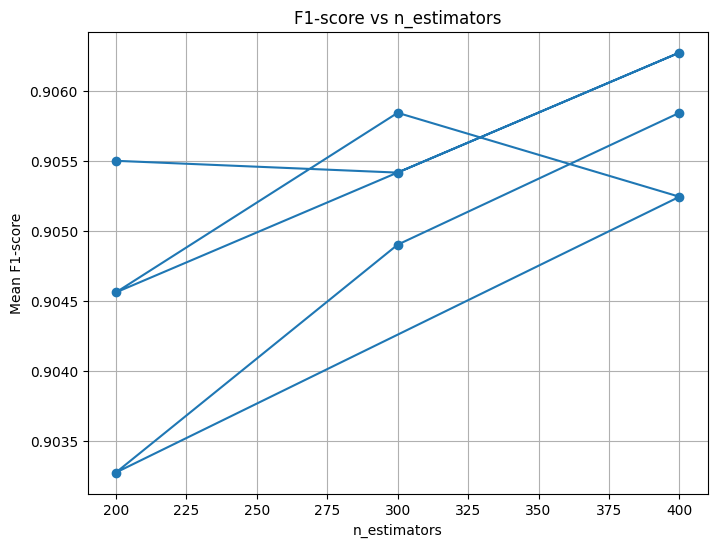

In [7]:
# get best parameter for random forest if mean pooling is used
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# load embedding from .npy file
X_embeddings = np.load("./embed/embeddings_128_v2.npy")

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1],
    'class_weight': ['balanced']
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# Grid Search with StratifiedKFold
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=4),
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1',  # Optimize for weighted F1-score
    n_jobs=-1,
    verbose=2
)

search.fit(X_embeddings, y)

print("Best parameters:", search.best_params_)
print("Best cross-validated score:", search.best_score_)

import pandas as pd

results = pd.DataFrame(search.cv_results_)
print(results[['param_n_estimators', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])


import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)
plt.figure(figsize=(8,6))
plt.plot(results['param_n_estimators'], results['mean_test_f1'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Mean F1-score')
plt.title('F1-score vs n_estimators')
plt.grid(True)
plt.show()

# results.to_csv("result/gridsearch_results.csv", index=False)


c:\Users\Marvel Wilbert O\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best parameters: {'n_estimators': 400, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best cross-validated score: 0.9016527673727734
   param_n_estimators  mean_test_accuracy  mean_test_f1  mean_test_precision  \
0                 200            0.900113      0.900108             0.901227   
1                 300            0.901310      0.901307             0.902379   
2                 400            0.901652      0.901648             0.902717   
3                 200            0.900882      0.900878             0.901947   
4                 300            0.901652      0.901651             0.902643   
5                 400            0.901651      0.901653             0.902550   
6                 200            0.899257      0.899252             0.900292   
7                 300            0.899000      0.898998             0.900001   
8                 400            0.8993

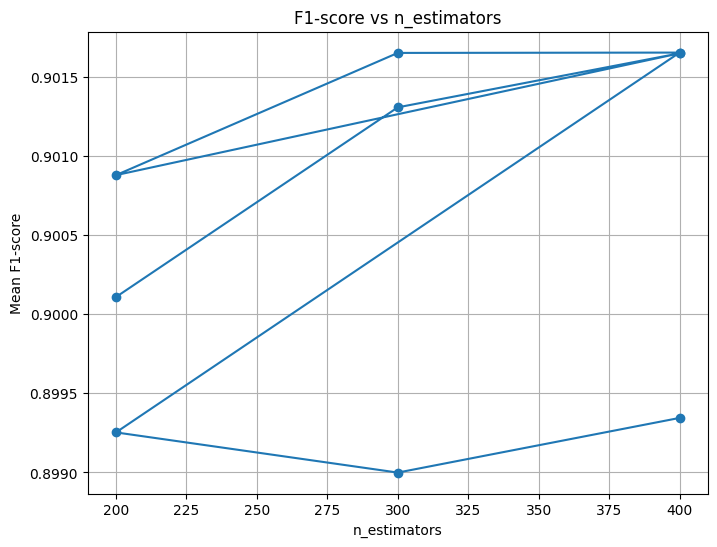

In [6]:
# get best parameter for random forest if cls pooling is used
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# load embedding from .npy file
X_embeddings = np.load("./embed/embeddings_128_v1.npy")

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1],
    'class_weight': ['balanced']
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# Grid Search with StratifiedKFold
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=4),
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1',  # Optimize for weighted F1-score
    n_jobs=4,
    verbose=2
)

search.fit(X_embeddings, y)

print("Best parameters:", search.best_params_)
print("Best cross-validated score:", search.best_score_)

import pandas as pd

results = pd.DataFrame(search.cv_results_)
print(results[['param_n_estimators', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])


import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)
plt.figure(figsize=(8,6))
plt.plot(results['param_n_estimators'], results['mean_test_f1'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Mean F1-score')
plt.title('F1-score vs n_estimators')
plt.grid(True)
plt.show()

# results.to_csv("result/gridsearch_results.csv", index=False)


Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'class_weight': None, 'kernel': 'rbf'}
Best Cross-Validated F1: 0.9385171373686478


,param_C,param_kernel,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,1,rbf,0.933806,0.933814,0.934185,0.933806
1,1,poly,0.937227,0.937234,0.937338,0.937227
2,1,rbf,0.934319,0.934328,0.934783,0.934319
3,1,poly,0.937313,0.937321,0.937460,0.937313
4,10,rbf,0.938509,0.938517,0.938704,0.938509
5,10,poly,0.936371,0.936374,0.936445,0.936371
6,10,rbf,0.938424,0.938431,0.938631,0.938424
7,10,poly,0.936457,0.936460,0.936531,0.936457
8,50,rbf,0.936029,0.936036,0.936197,0.936029
9,50,poly,0.932779,0.932782,0.932864,0.932779


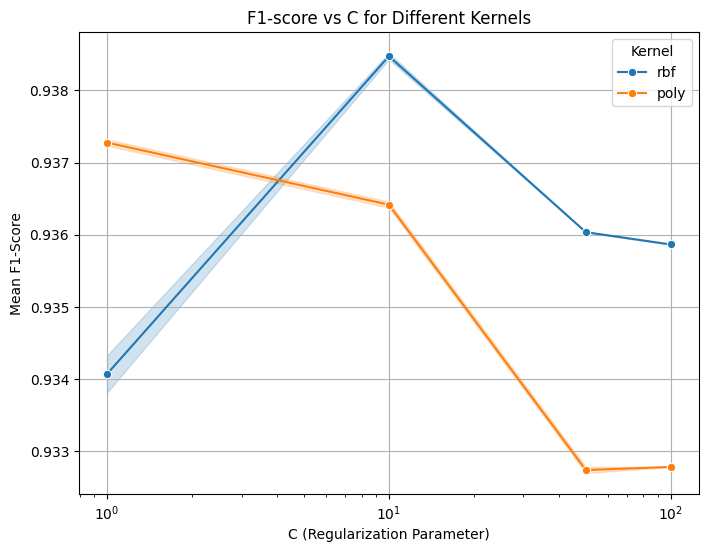

In [ ]:
# get best parameter for support vector machine if mean pooling is used
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, make_scorer
)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Load Data
# ==============================
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# Load embeddings (contoh: hasil IndoBERTweet)
X_embeddings = np.load("./embed/embeddings_128_v2.npy")

# ==============================
# Define Stratified K-Fold
# ==============================
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# ==============================
# Define Parameter Grid untuk SVC
# ==============================
param_grid = {
    'C': [ 1, 10, 50],                   # Regularization parameter
    'kernel': ['rbf', 'poly'],               # Kernel coefficient
    'class_weight': ['balanced']        # Handle imbalance
}

# ==============================
# Define Scoring Metrics
# ==============================
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# ==============================
# Grid Search CV
# ==============================
search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    scoring=scoring,
    refit='f1',            # Refit model based on the best F1 score
    cv=skf,
    verbose=2,
    n_jobs=-1
)

# ==============================
# Fit Model
# ==============================
search.fit(X_embeddings, y)

# ==============================
# Print Results
# ==============================
print("Best Parameters:", search.best_params_)
print("Best Cross-Validated F1:", search.best_score_)

# Convert results ke DataFrame
results = pd.DataFrame(search.cv_results_)

# Tampilkan beberapa metrik utama
display(results[['param_C', 'param_kernel', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])

# ==============================
# Visualisasi Hasil
# ==============================
plt.figure(figsize=(8, 6))
sns.lineplot(data=results, x='param_C', y='mean_test_f1', hue='param_kernel', marker='o')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean F1-Score')
plt.title('F1-score vs C for Different Kernels')
plt.grid(True)
plt.legend(title='Kernel')
plt.show()

# ==============================
# (Optional) Simpan Hasil
# ==============================
# results.to_csv("result/gridsearch_svc_results.csv", index=False)


Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'kernel': 'poly'}
Best Cross-Validated F1: 0.9342418109981336


,param_C,param_kernel,mean_test_accuracy,mean_test_f1,mean_test_precision,mean_test_recall
0,1,rbf,0.928503,0.928513,0.928910,0.928503
1,1,poly,0.932609,0.932617,0.933097,0.932609
2,10,rbf,0.933891,0.933899,0.934058,0.933891
3,10,poly,0.934234,0.934242,0.934441,0.934234
4,50,rbf,0.933293,0.933301,0.933479,0.933293
5,50,poly,0.933550,0.933558,0.933785,0.933550


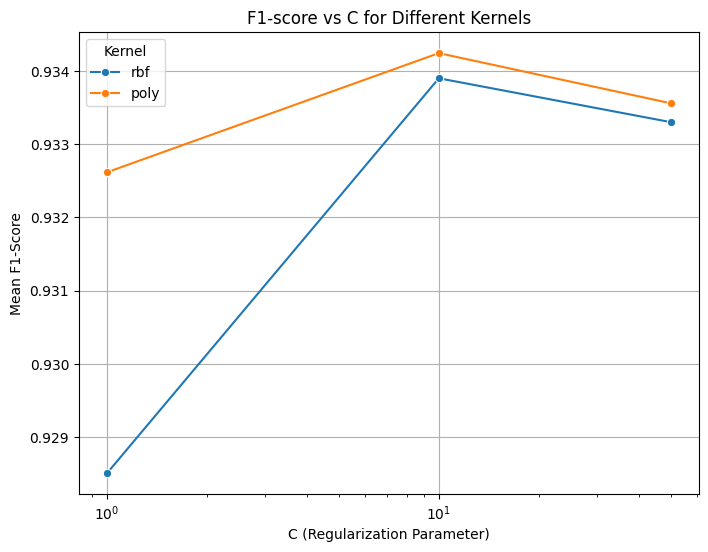

In [6]:
# get best parameter for support vector machine if cls pooling is used
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, make_scorer
)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Load Data
# ==============================
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# Load embeddings (contoh: hasil IndoBERTweet)
X_embeddings = np.load("./embed/embeddings_128_v1.npy")

# ==============================
# Define Stratified K-Fold
# ==============================
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# ==============================
# Define Parameter Grid untuk SVC
# ==============================
param_grid = {
    'C': [1, 10, 50],                   # Regularization parameter
    'kernel': ['rbf', 'poly'],
    'class_weight': ['balanced']        # Handle imbalance
}

# ==============================
# Define Scoring Metrics
# ==============================
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# ==============================
# Grid Search CV
# ==============================
search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    scoring=scoring,
    refit='f1',            # Refit model based on the best F1 score
    cv=skf,
    verbose=2,
    n_jobs=-1
)

# ==============================
# Fit Model
# ==============================
search.fit(X_embeddings, y)

# ==============================
# Print Results
# ==============================
print("Best Parameters:", search.best_params_)
print("Best Cross-Validated F1:", search.best_score_)

# Convert results ke DataFrame
results = pd.DataFrame(search.cv_results_)

# Tampilkan beberapa metrik utama
display(results[['param_C', 'param_kernel', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])

# ==============================
# Visualisasi Hasil
# ==============================
plt.figure(figsize=(8, 6))
sns.lineplot(data=results, x='param_C', y='mean_test_f1', hue='param_kernel', marker='o')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean F1-Score')
plt.title('F1-score vs C for Different Kernels')
plt.grid(True)
plt.legend(title='Kernel')
plt.show()

# ==============================
# (Optional) Simpan Hasil
# ==============================
# results.to_csv("result/gridsearch_svc_results.csv", index=False)


In [4]:
from sklearn.model_selection import StratifiedKFold

# Get IndoBERTweet embeddings for all texts
X_embeddings = np.load("./embed/embeddings_128_v2.npy")
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_reports = []
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0

for fold, (train_idx, test_idx) in enumerate(skf.split(X_embeddings, y)):
    X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
    y_train, y_test = np.array(y)[train_idx], np.array(y)[test_idx]

    rf = RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_split=3, min_samples_leaf=1, random_state=42, class_weight=None, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))


Fold 1: 0.9102564102564102


,precision,recall,f1-score,support
0,0.894737,0.924561,0.909405,570.000000
1,0.925990,0.896667,0.911092,600.000000
accuracy,0.910256,0.910256,0.910256,0.910256
macro avg,0.910363,0.910614,0.910248,1170.000000
weighted avg,0.910764,0.910256,0.910270,1170.000000


Fold 2: 0.9145299145299145


,precision,recall,f1-score,support
0,0.881494,0.952632,0.915683,570.00000
1,0.951264,0.878333,0.913345,600.00000
accuracy,0.914530,0.914530,0.914530,0.91453
macro avg,0.916379,0.915482,0.914514,1170.00000
weighted avg,0.917273,0.914530,0.914484,1170.00000


Fold 3: 0.9051282051282051


...

,precision,recall,f1-score,score
class 0,0.884620,0.927530,0.905524,NaN
class 1,0.927837,0.884885,0.905805,NaN
accuracy,NaN,NaN,NaN,0.905669
macro avg,0.906228,0.906208,0.905665,NaN
weighted avg,0.906774,0.905669,0.905668,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.910256
1,2,0.914530
2,3,0.905128
3,4,0.900770
4,5,0.922156
5,6,0.911891
6,7,0.895637
7,8,0.893071
8,9,0.902481
9,10,0.900770


Confusion Matrix across all folds:


,0,1
0,5286,413
1,690,5304


In [3]:
# SVM Classifier with IndoBERTweet Embeddings
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

# Get IndoBERTweet embeddings for all texts (reuse if already computed)
X_embeddings = np.load("./embed/embeddings_128_v2.npy")
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_reports = []
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0

for fold, (train_idx, test_idx) in enumerate(skf.split(X_embeddings, y)):
    X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
    y_train, y_test = np.array(y)[train_idx], np.array(y)[test_idx]

    # Initialize and train SVM (RBF kernel as default, can tune parameters)
    svm = SVC(kernel='rbf', C=10, class_weight=None, random_state=42)
    svm.fit(X_train, y_train)
    # Predict and evaluate
    y_pred = svm.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    # fold += 1

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}


# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))


Fold 1: 0.935042735042735


,precision,recall,f1-score,support
0,0.924399,0.943860,0.934028,570.000000
1,0.945578,0.926667,0.936027,600.000000
accuracy,0.935043,0.935043,0.935043,0.935043
macro avg,0.934988,0.935263,0.935027,1170.000000
weighted avg,0.935260,0.935043,0.935053,1170.000000


Fold 2: 0.9427350427350427


,precision,recall,f1-score,support
0,0.931389,0.952632,0.941891,570.000000
1,0.954003,0.933333,0.943555,600.000000
accuracy,0.942735,0.942735,0.942735,0.942735
macro avg,0.942696,0.942982,0.942723,1170.000000
weighted avg,0.942986,0.942735,0.942744,1170.000000


Fold 3: 0.9487179487179487


...

,precision,recall,f1-score,score
class 0,0.929209,0.945955,0.937490,NaN
class 1,0.947731,0.931432,0.939494,NaN
accuracy,NaN,NaN,NaN,0.938509
macro avg,0.938470,0.938693,0.938492,NaN
weighted avg,0.938704,0.938509,0.938517,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.935043
1,2,0.942735
2,3,0.948718
3,4,0.933276
4,5,0.961506
5,6,0.934132
6,7,0.930710
7,8,0.932421
8,9,0.934987
9,10,0.931565


Confusion Matrix across all folds:


,0,1
0,5391,308
1,411,5583
